In [121]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats as sps
from tqdm import tqdm
df = pd.read_csv('BAC_1min_OHLC.csv', parse_dates={'Full_date': ['Date', 'Time']}, date_format='%Y-%m-%d %H:%M:%S')
df.set_index('Full_date', inplace=True)
df['Log_Close'] = np.log(df['Close'])
n = df.shape[0]
df.head()

/tmp/ipykernel_947/1839188835.py:7: FutureWarning: Support for nested sequences for 'parse_dates' in pd.read_csv is deprecated. Combine the desired columns with pd.to_datetime after parsing instead.
  df = pd.read_csv('BAC_1min_OHLC.csv', parse_dates={'Full_date': ['Date', 'Time']}, date_format='%Y-%m-%d %H:%M:%S')


,Open,High,Low,Close,Log_Close
Full_date,,,,,
2014-01-02 09:30:00,15.6900,15.730,15.680,15.72,2.754934
2014-01-02 09:31:00,15.7199,15.740,15.700,15.73,2.755570
2014-01-02 09:32:00,15.7200,15.760,15.720,15.76,2.757475
2014-01-02 09:33:00,15.7599,15.800,15.755,15.79,2.759377
2014-01-02 09:34:00,15.8000,15.825,15.790,15.81,2.760643


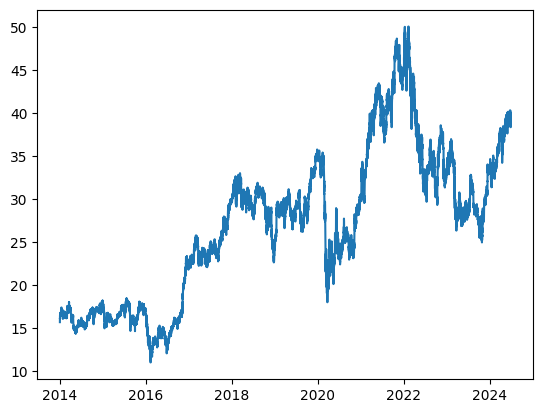

In [111]:
plt.plot(df.Open);

In [112]:
intervals = ['1min', '5min', '10min']
rv_results = pd.DataFrame()

for freq in intervals:
    daily_rv = df.groupby(df.index.date).apply(
        lambda day: (day['Log_Close'].resample(freq).last().dropna().diff().dropna() ** 2).sum()
    )
    rv_results[freq] = daily_rv

print(rv_results.describe())

              1min         5min        10min
count  2640.000000  2640.000000  2640.000000
mean      0.000236     0.000208     0.000190
std       0.000388     0.000386     0.000348
min       0.000033     0.000014     0.000011
25%       0.000111     0.000083     0.000070
50%       0.000158     0.000132     0.000117
75%       0.000243     0.000213     0.000200
max       0.008009     0.008141     0.006935


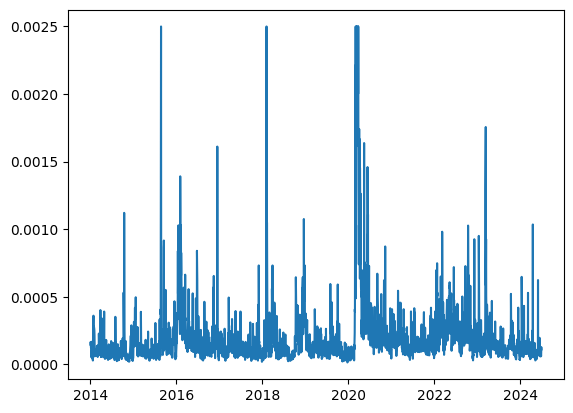

In [113]:
plt.plot(np.clip(a_min=0, a_max=0.0025, a=rv_results['5min']))

Исходя из отношения $\frac{\overline{RV_{10min}}}{\overline{RV_{11min}}} \approx 0.75 \Rightarrow$ микроструктурный шум присутствует.

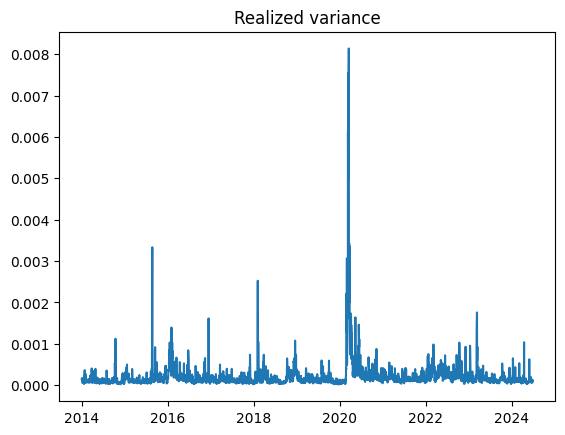

In [155]:
plt.plot(rv_results['5min'])
plt.title('Realized variance');

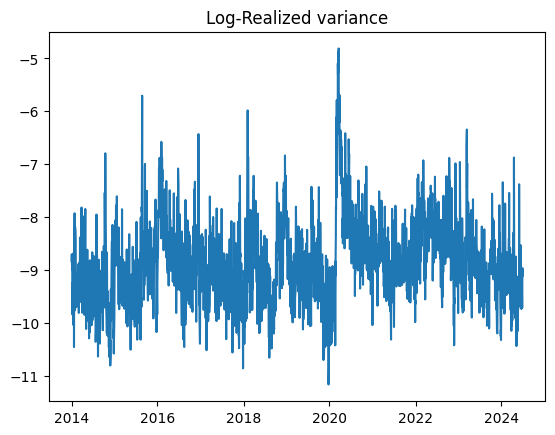

In [156]:
plt.plot(np.log(rv_results['5min']))
plt.title('Log-Realized variance');

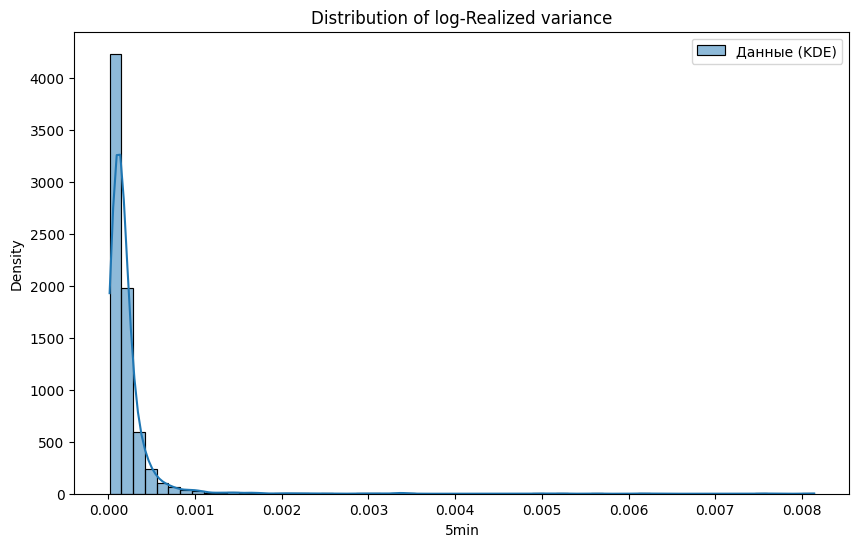

In [187]:
data = rv_results['5min']

plt.figure(figsize=(10, 6))
sns.histplot(data, bins=60, kde=True, stat="density", label='Данные (KDE)')


plt.legend()
plt.title('Distribution of log-Realized variance');

Основная масса сконцтрирована вблизи 0 (и в близи нуля для нелогорифмированного случая), но, из-за редких выбросов (2015, 2018, 2020 годы) хвост будет тяжелее, чем теор. распределение.

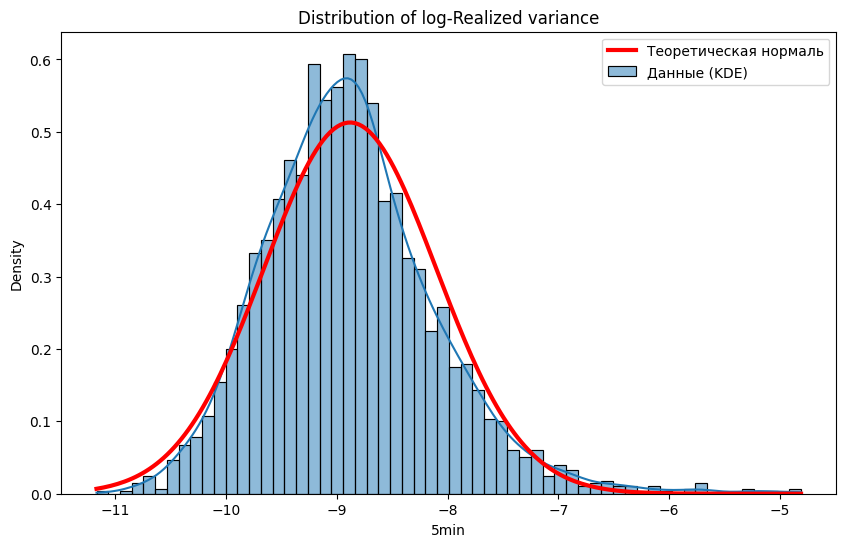

In [157]:
data = np.log(rv_results['5min'])

x_min, x_max = data.min(), data.max()
x = np.linspace(x_min, x_max, 200)

norm_pdf = sps.norm.pdf(x, loc=data.mean(), scale=data.std())
plt.figure(figsize=(10, 6))
sns.histplot(data, bins=60, kde=True, stat="density", label='Данные (KDE)')

plt.plot(x, norm_pdf, color='red', lw=3, label='Теоретическая нормаль')

plt.legend()
plt.title('Distribution of log-Realized variance');

При логарифмировании, напротив, хвосты будут сжиматься относительно теор распределения. В слайдах доказывается факт, что log(RV) распределен нормально с параметрыми среднего и std

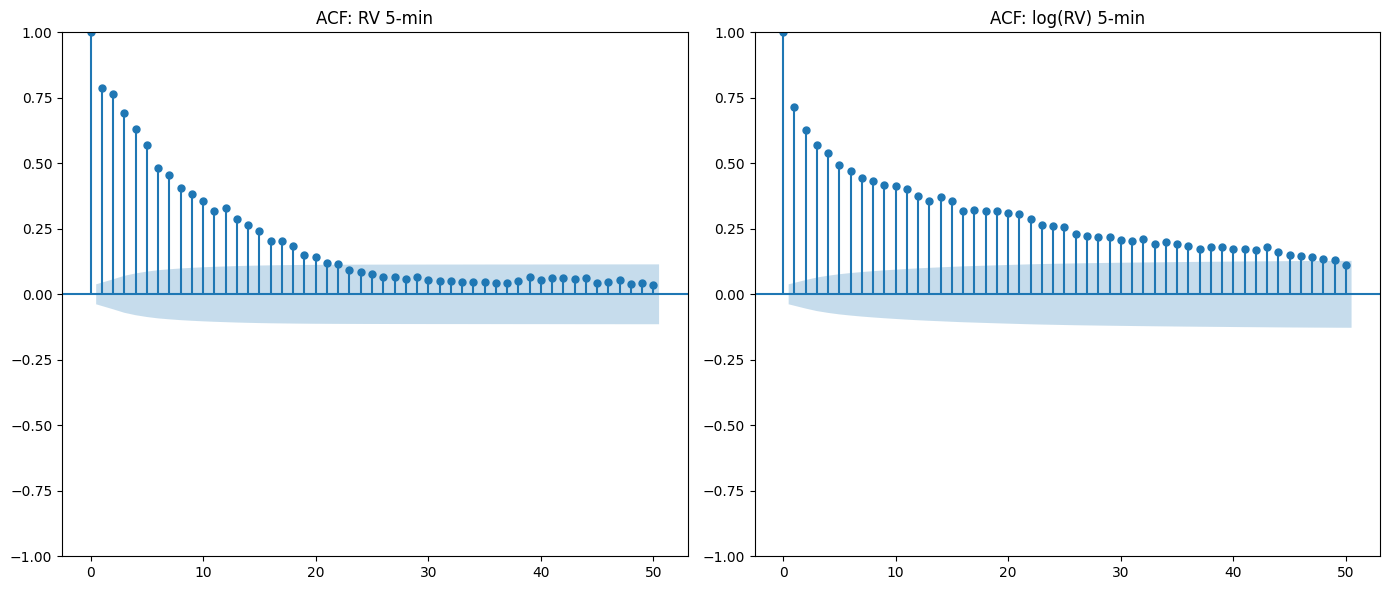

In [164]:
from statsmodels.graphics.tsaplots import plot_acf

rv_5min = rv_results['5min'].dropna()
log_rv_5min = np.log(rv_5min)

df_stats = pd.DataFrame({'RV_5min': rv_5min, 'log_RV_5min': log_rv_5min})


fig, axes = plt.subplots(1, 2, figsize=(14, 6))

plot_acf(df_stats['RV_5min'], lags=50, ax=axes[0], title='ACF: RV 5-min')
plot_acf(df_stats['log_RV_5min'], lags=50, ax=axes[1], title='ACF: log(RV) 5-min')

plt.tight_layout()
plt.show()

Судя по графикам автокореляционной функции (гиперболическим), рализованная вариация имеет свойство длинной памяти.


In [196]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from catboost import CatBoostRegressor

daily_data = rv_results[['5min']].rename(columns={'5min': 'RV'})
daily_data['log_RV'] = np.log(daily_data['RV'])

daily_data['Returns'] = df['Log_Close'].resample('D').last().diff()
daily_data['Leverage'] = np.minimum(daily_data['Returns'], 0)

for col in ['RV', 'log_RV']:
    daily_data[f'{col}_w'] = daily_data[col].rolling(window=5).mean()
    daily_data[f'{col}_m'] = daily_data[col].rolling(window=22).mean()

daily_data = daily_data.dropna()

split_idx = int(len(daily_data) * 0.7)
train, test = daily_data.iloc[:split_idx], daily_data.iloc[split_idx:]

models = {
    'HAR_RV': ('RV', ['RV', 'RV_w', 'RV_m']),
    'HAR_logRV': ('log_RV', ['log_RV', 'log_RV_w', 'log_RV_m']),
    'HAR_logRV_Lev': ('log_RV', ['log_RV', 'log_RV_w', 'log_RV_m', 'Leverage']),
    'CatBoost_RV': ('RV', ['RV', 'RV_w', 'RV_m']),
    'CatBoost_logRV': ('log_RV', ['log_RV', 'log_RV_w', 'log_RV_m']),
    'CatBoost_logRV_Lev': ('log_RV', ['log_RV', 'log_RV_w', 'log_RV_m', 'Leverage'])
}

mse_results = {}

for name, (target, features) in models.items():
    X_train, y_train = train[features], train[target]
    X_test, y_test = test[features], test[target]

    model = LinearRegression()
    model.fit(X_train, y_train)
    preds = model.predict(X_test)

    if 'CatBoost' in name:
        model = CatBoostRegressor(verbose=False)
        model.fit(X_train, y_train)
        preds = model.predict(X_test)

    mse_results[name] = mean_squared_error(y_test, preds)

print(pd.Series(mse_results))

HAR_RV                1.365941e-39
HAR_logRV             8.949800e-32
HAR_logRV_Lev         4.858463e-32
CatBoost_RV           8.009303e-11
CatBoost_logRV        2.167723e-04
CatBoost_logRV_Lev    2.370844e-04
dtype: float64


Результаты и так, какжется, на грани погрешности, поэтому подбор различных моделей не имеет смысла. 